<a href="https://colab.research.google.com/github/Carozuhe/Problema_bancario/blob/main/Problema_bancario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   LABORATORIO: PROBLEMA BANCARIO - SIMULACIÓN DE COLAS M/M/1
   Banco de Colombia - Optimización de Cajeros

   ESCENARIO 1: 3 CAJAS MIXTAS (configuración actual)
  Réplica 1/10 completada - 208 clientes atendidos
  Réplica 2/10 completada - 181 clientes atendidos
  Réplica 3/10 completada - 200 clientes atendidos
  Réplica 4/10 completada - 196 clientes atendidos
  Réplica 5/10 completada - 193 clientes atendidos
  Réplica 6/10 completada - 206 clientes atendidos
  Réplica 7/10 completada - 182 clientes atendidos
  Réplica 8/10 completada - 203 clientes atendidos
  Réplica 9/10 completada - 199 clientes atendidos
  Réplica 10/10 completada - 217 clientes atendidos

   ESCENARIO 2: 1 CAJA RETIROS + 2 CAJAS PAGOS
  Réplica 1/10 completada - 193 clientes atendidos
  Réplica 2/10 completada - 162 clientes atendidos
  Réplica 3/10 completada - 204 clientes atendidos
  Réplica 4/10 completada - 196 clientes atendidos
  Réplica 5/10 completada - 176 clientes atendidos
  Réplica 6/10 complet

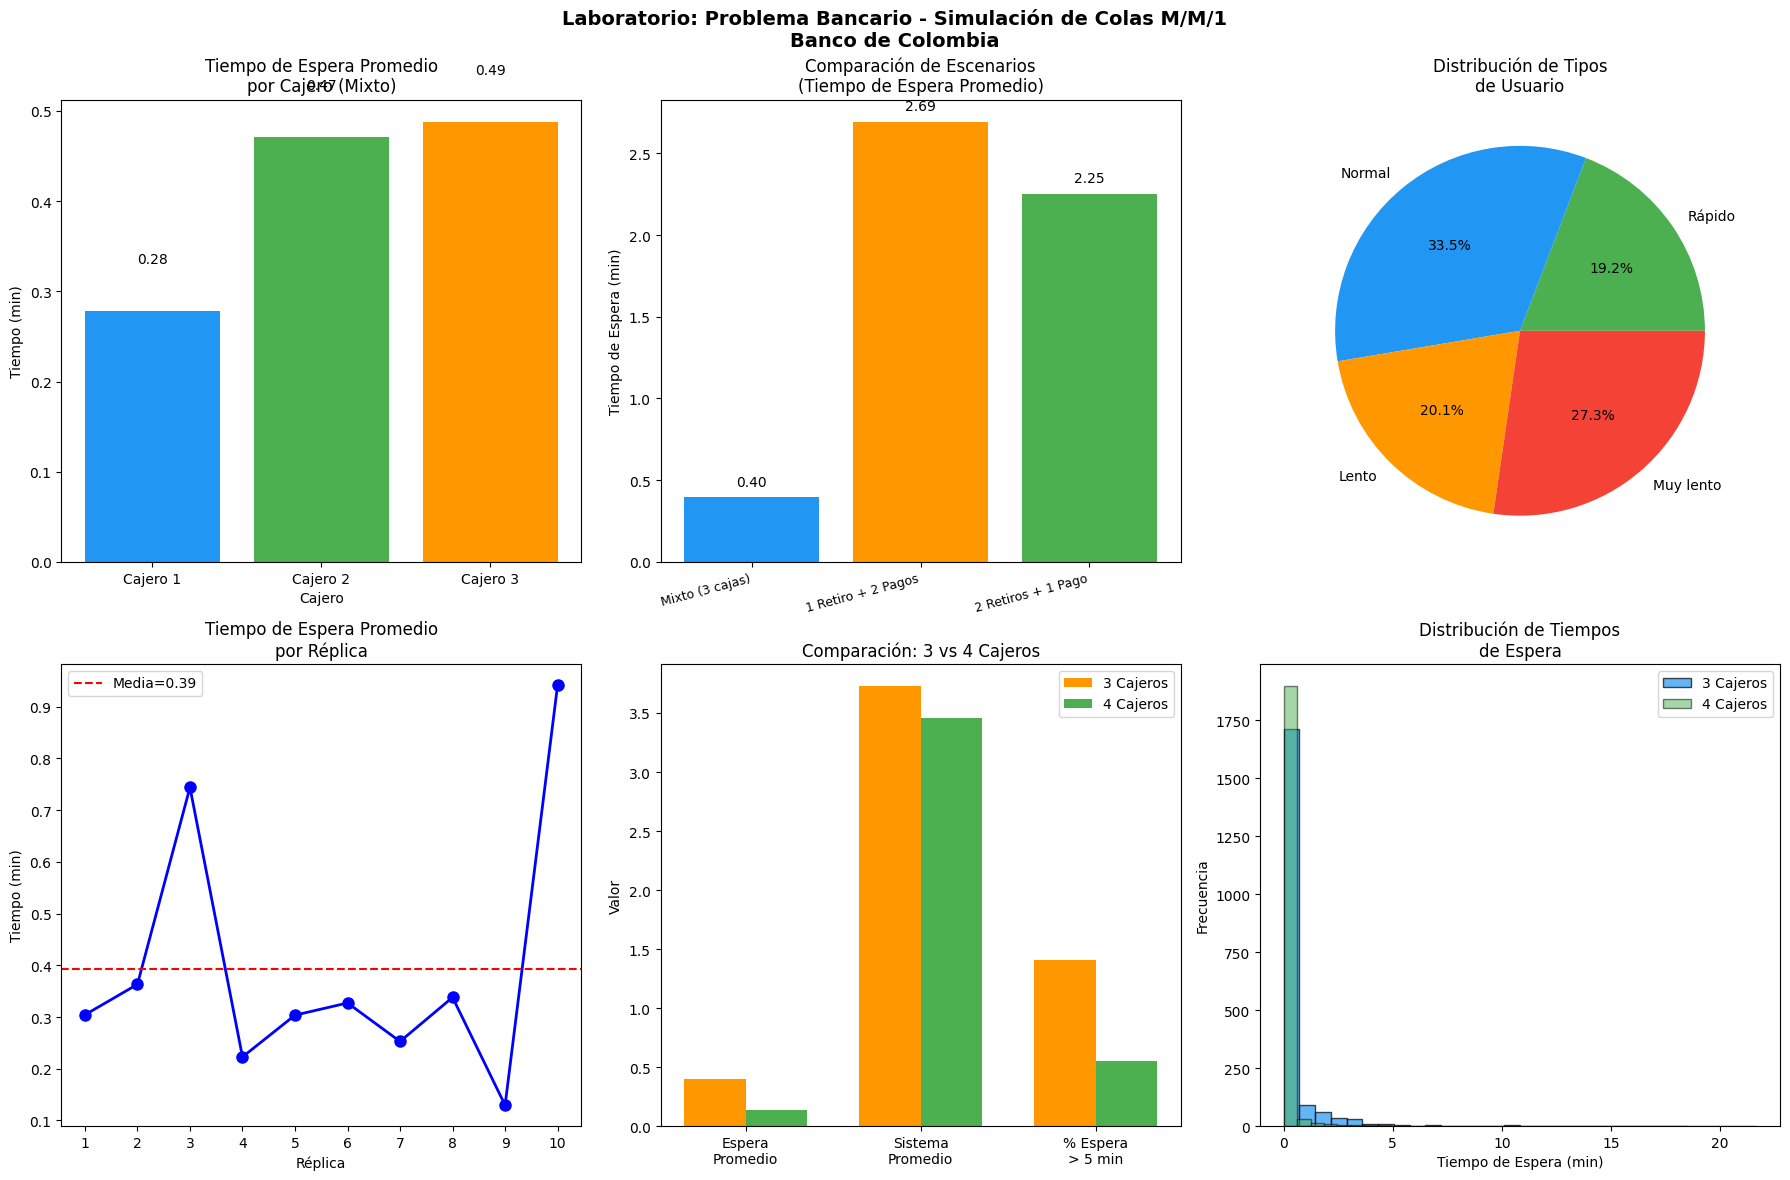


✅ Gráfica guardada como 'resultados_simulacion_banco.png'


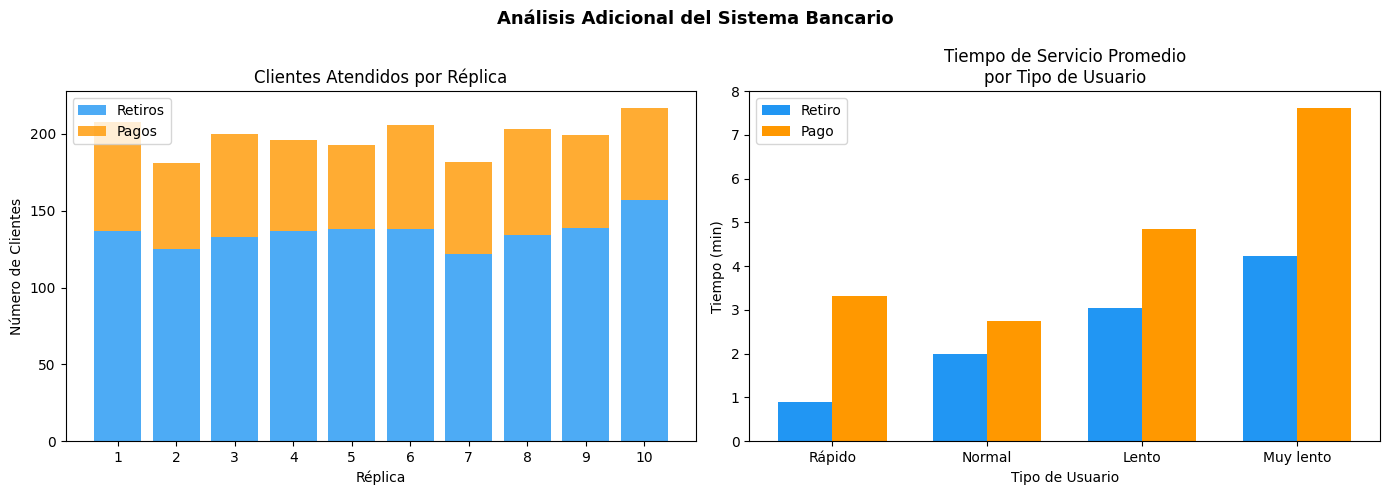

✅ Gráfica adicional guardada como 'analisis_adicional_banco.png'

   RESUMEN FINAL Y CONCLUSIONES

╔══════════════════════════════════════════════════════════════════════╗
║                    CONCLUSIONES DEL LABORATORIO                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PUNTO 1: Se identificó el cajero con menor y mayor tiempo de       ║
║           atención promedio en la configuración mixta.               ║
║                                                                      ║
║  PUNTO 2: Se calculó el promedio de usuarios por tipo (Rápido,      ║
║           Normal, Lento, Muy lento) en todos los cajeros.           ║
║                                                                      ║
║  PUNTO 3: Se determinó el total de usuarios por tipo en cada        ║
║           réplica y se identificó la réplica con menor cantidad.    ║
║                              

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CLASE PRINCIPAL DE SIMULACIÓN
# =============================================================================

class BankSimulation:
    """
    Simulación de un sistema bancario con múltiples cajeros (M/M/1).
    Modela llegadas y servicios con distribución exponencial.
    """

    def __init__(self, num_cajeros=3, horas_operacion=8, configuracion='mixto'):
        self.num_cajeros = num_cajeros
        self.tiempo_simulacion = horas_operacion * 60  # minutos
        self.configuracion = configuracion

        # Probabilidades de tipo de acción
        self.prob_retiro = 0.70
        self.prob_pago = 0.30

        # Probabilidades de tipo de usuario (Rápido, Normal, Lento, Muy lento)
        self.prob_usuario_retiro = [0.23, 0.40, 0.17, 0.20]
        self.prob_usuario_pago = [0.10, 0.20, 0.30, 0.40]

        # Medias de tiempo de servicio (minutos) - distribución exponencial
        self.servicio_retiro = [1, 2, 3, 4]
        self.servicio_pago = [3, 3, 5, 7]

        # Medias de tiempo entre llegadas (minutos) - distribución exponencial
        self.llegada_retiro = [1, 2, 3, 3]
        self.llegada_pago = [1, 2, 3, 4]

        # Nombres para reportes
        self.nombres_tipo_usuario = ['Rápido', 'Normal', 'Lento', 'Muy lento']
        self.nombres_tipo_accion = ['Retiro', 'Pago']

    def _asignar_cajero(self, tipo_accion, cajeros_disponibles):
        """
        Asigna un cajero según la configuración.
        - mixto: cualquier cajero disponible
        - 1r2p: cajero 0 solo retiros, cajeros 1-2 solo pagos
        - 2r1p: cajeros 0-1 solo retiros, cajero 2 solo pagos
        """
        if self.configuracion == 'mixto':
            for i in cajeros_disponibles:
                return i
            return None

        elif self.configuracion == '1r2p':
            # Cajero 0: retiros | Cajeros 1,2: pagos
            if tipo_accion == 'retiro':
                if 0 in cajeros_disponibles:
                    return 0
            else:
                for i in [1, 2]:
                    if i in cajeros_disponibles:
                        return i
            return None

        elif self.configuracion == '2r1p':
            # Cajeros 0,1: retiros | Cajero 2: pagos
            if tipo_accion == 'retiro':
                for i in [0, 1]:
                    if i in cajeros_disponibles:
                        return i
            else:
                if 2 in cajeros_disponibles:
                    return 2
            return None

        return None

    def _puede_atender(self, cajero_id, tipo_accion):
        """Verifica si un cajero puede atender un tipo de acción según configuración."""
        if self.configuracion == 'mixto':
            return True
        elif self.configuracion == '1r2p':
            if tipo_accion == 'retiro':
                return cajero_id == 0
            else:
                return cajero_id in [1, 2]
        elif self.configuracion == '2r1p':
            if tipo_accion == 'retiro':
                return cajero_id in [0, 1]
            else:
                return cajero_id == 2
        return True

    def simular_dia(self, semilla=None):
        """
        Simula un día completo de operación del banco usando simulación
        de eventos discretos con disciplina de cola PRIORITY (non-preemptive).
        Prioridad: Rápido (0) > Normal (1) > Lento (2) > Muy lento (3)
        (menor número = mayor prioridad)
        """
        import heapq

        if semilla is not None:
            np.random.seed(semilla)

        # Lista de eventos: (tiempo, tipo_evento, datos)
        # tipo_evento: 'llegada' o 'fin_servicio'
        eventos = []
        contador_eventos = 0  # Para desempate en heapq

        # Estado de cajeros: None = libre, tiempo_fin = ocupado
        cajeros_estado = [None] * self.num_cajeros  # None=libre, float=tiempo_fin

        # Cola de prioridad: lista de (prioridad, orden_llegada, tiempo_llegada, tipo_accion, tipo_usuario)
        cola_prioridad = []
        orden_llegada = 0  # Para FIFO dentro de misma prioridad

        # Registros
        clientes_atendidos = []

        # Programar primera llegada
        tipo_accion = 'retiro' if np.random.random() < self.prob_retiro else 'pago'
        tipo_usuario = self._generar_tipo_usuario(tipo_accion)
        if tipo_accion == 'retiro':
            t_llegada = np.random.exponential(self.llegada_retiro[tipo_usuario])
        else:
            t_llegada = np.random.exponential(self.llegada_pago[tipo_usuario])

        heapq.heappush(eventos, (t_llegada, contador_eventos, 'llegada', tipo_accion, tipo_usuario, None))
        contador_eventos += 1

        while eventos:
            tiempo_actual, _, tipo_evento, *datos = heapq.heappop(eventos)

            if tiempo_actual > self.tiempo_simulacion and tipo_evento == 'llegada':
                break

            if tipo_evento == 'llegada':
                tipo_accion_cli = datos[0]
                tipo_usuario_cli = datos[1]

                # Buscar cajero disponible para este tipo de acción
                cajero_asignado = None
                for i in range(self.num_cajeros):
                    if cajeros_estado[i] is None and self._puede_atender(i, tipo_accion_cli):
                        cajero_asignado = i
                        break

                if cajero_asignado is not None:
                    # Atender inmediatamente
                    if tipo_accion_cli == 'retiro':
                        tiempo_servicio = np.random.exponential(self.servicio_retiro[tipo_usuario_cli])
                    else:
                        tiempo_servicio = np.random.exponential(self.servicio_pago[tipo_usuario_cli])

                    fin_servicio = tiempo_actual + tiempo_servicio
                    cajeros_estado[cajero_asignado] = fin_servicio

                    # Programar fin de servicio
                    heapq.heappush(eventos, (fin_servicio, contador_eventos, 'fin_servicio',
                                             cajero_asignado, tipo_accion_cli, tipo_usuario_cli))
                    contador_eventos += 1

                    clientes_atendidos.append({
                        'tipo_accion': tipo_accion_cli,
                        'tipo_usuario': tipo_usuario_cli,
                        'nombre_tipo_usuario': self.nombres_tipo_usuario[tipo_usuario_cli],
                        'tiempo_llegada': tiempo_actual,
                        'tiempo_espera': 0.0,
                        'tiempo_servicio': tiempo_servicio,
                        'tiempo_sistema': tiempo_servicio,
                        'cajero': cajero_asignado,
                        'inicio_servicio': tiempo_actual,
                        'fin_servicio': fin_servicio
                    })
                else:
                    # Todos los cajeros ocupados: encolar con prioridad
                    heapq.heappush(cola_prioridad,
                                   (tipo_usuario_cli, orden_llegada, tiempo_actual, tipo_accion_cli, tipo_usuario_cli))
                    orden_llegada += 1

                # Programar siguiente llegada
                tipo_accion_nueva = 'retiro' if np.random.random() < self.prob_retiro else 'pago'
                tipo_usuario_nuevo = self._generar_tipo_usuario(tipo_accion_nueva)
                if tipo_accion_nueva == 'retiro':
                    dt = np.random.exponential(self.llegada_retiro[tipo_usuario_nuevo])
                else:
                    dt = np.random.exponential(self.llegada_pago[tipo_usuario_nuevo])

                heapq.heappush(eventos, (tiempo_actual + dt, contador_eventos, 'llegada',
                                         tipo_accion_nueva, tipo_usuario_nuevo, None))
                contador_eventos += 1

            elif tipo_evento == 'fin_servicio':
                cajero_id = datos[0]
                cajeros_estado[cajero_id] = None  # Liberar cajero

                # Buscar en cola de prioridad al siguiente cliente que este cajero pueda atender
                # Extraer todos, buscar el adecuado, re-insertar los demás
                temp = []
                cliente_encontrado = None

                while cola_prioridad:
                    item = heapq.heappop(cola_prioridad)
                    prio, orden, t_lleg, t_acc, t_usr = item
                    if cliente_encontrado is None and self._puede_atender(cajero_id, t_acc):
                        cliente_encontrado = item
                    else:
                        temp.append(item)

                # Re-insertar los no seleccionados
                for item in temp:
                    heapq.heappush(cola_prioridad, item)

                if cliente_encontrado is not None:
                    prio, orden, t_lleg, t_acc, t_usr = cliente_encontrado
                    tiempo_espera = tiempo_actual - t_lleg

                    if t_acc == 'retiro':
                        tiempo_servicio = np.random.exponential(self.servicio_retiro[t_usr])
                    else:
                        tiempo_servicio = np.random.exponential(self.servicio_pago[t_usr])

                    fin_servicio = tiempo_actual + tiempo_servicio
                    cajeros_estado[cajero_id] = fin_servicio

                    heapq.heappush(eventos, (fin_servicio, contador_eventos, 'fin_servicio',
                                             cajero_id, t_acc, t_usr))
                    contador_eventos += 1

                    clientes_atendidos.append({
                        'tipo_accion': t_acc,
                        'tipo_usuario': t_usr,
                        'nombre_tipo_usuario': self.nombres_tipo_usuario[t_usr],
                        'tiempo_llegada': t_lleg,
                        'tiempo_espera': tiempo_espera,
                        'tiempo_servicio': tiempo_servicio,
                        'tiempo_sistema': tiempo_espera + tiempo_servicio,
                        'cajero': cajero_id,
                        'inicio_servicio': tiempo_actual,
                        'fin_servicio': fin_servicio
                    })

        return pd.DataFrame(clientes_atendidos)

    def _generar_tipo_usuario(self, tipo_accion):
        """Genera tipo de usuario según probabilidades."""
        if tipo_accion == 'retiro':
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_retiro)
        else:
            return np.random.choice([0, 1, 2, 3], p=self.prob_usuario_pago)

    def _generar_siguiente_llegada(self, tiempo_actual):
        """Genera el siguiente cliente y su tiempo de llegada."""
        tipo_accion = 'retiro' if np.random.random() < self.prob_retiro else 'pago'
        tipo_usuario = self._generar_tipo_usuario(tipo_accion)

        if tipo_accion == 'retiro':
            tiempo_entre_llegadas = np.random.exponential(self.llegada_retiro[tipo_usuario])
        else:
            tiempo_entre_llegadas = np.random.exponential(self.llegada_pago[tipo_usuario])

        proxima_llegada = tiempo_actual + tiempo_entre_llegadas
        return tipo_accion, tipo_usuario, proxima_llegada

    def ejecutar_replicas(self, num_replicas=10):
        """Ejecuta múltiples réplicas de la simulación."""
        resultados = []
        for i in range(num_replicas):
            df = self.simular_dia(semilla=i * 42 + 7)
            df['replica'] = i + 1
            resultados.append(df)
            print(f"  Réplica {i+1}/{num_replicas} completada - {len(df)} clientes atendidos")
        return pd.concat(resultados, ignore_index=True)


# =============================================================================
# EJECUCIÓN DE LA SIMULACIÓN - ESCENARIO BASE (3 CAJAS MIXTAS)
# =============================================================================

print("=" * 70)
print("   LABORATORIO: PROBLEMA BANCARIO - SIMULACIÓN DE COLAS M/M/1")
print("   Banco de Colombia - Optimización de Cajeros")
print("=" * 70)

NUM_REPLICAS = 10

# --- ESCENARIO 1: 3 Cajas Mixtas ---
print("\n" + "=" * 70)
print("   ESCENARIO 1: 3 CAJAS MIXTAS (configuración actual)")
print("=" * 70)
sim_mixto = BankSimulation(num_cajeros=3, horas_operacion=8, configuracion='mixto')
resultados_mixto = sim_mixto.ejecutar_replicas(NUM_REPLICAS)

# --- ESCENARIO 2: 1 Retiro + 2 Pagos ---
print("\n" + "=" * 70)
print("   ESCENARIO 2: 1 CAJA RETIROS + 2 CAJAS PAGOS")
print("=" * 70)
sim_1r2p = BankSimulation(num_cajeros=3, horas_operacion=8, configuracion='1r2p')
resultados_1r2p = sim_1r2p.ejecutar_replicas(NUM_REPLICAS)

# --- ESCENARIO 3: 2 Retiros + 1 Pago ---
print("\n" + "=" * 70)
print("   ESCENARIO 3: 2 CAJAS RETIROS + 1 CAJA PAGOS")
print("=" * 70)
sim_2r1p = BankSimulation(num_cajeros=3, horas_operacion=8, configuracion='2r1p')
resultados_2r1p = sim_2r1p.ejecutar_replicas(NUM_REPLICAS)

# --- ESCENARIO 4: 4 Cajas Mixtas ---
print("\n" + "=" * 70)
print("   ESCENARIO 4: 4 CAJAS MIXTAS (evaluar necesidad)")
print("=" * 70)
sim_4cajas = BankSimulation(num_cajeros=4, horas_operacion=8, configuracion='mixto')
resultados_4cajas = sim_4cajas.ejecutar_replicas(NUM_REPLICAS)

# =============================================================================
# PUNTO 1: CAJERO CON MENOR Y MAYOR TIEMPO PROMEDIO DE ATENCIÓN
# =============================================================================

print("\n" + "=" * 70)
print("   PUNTO 1: CAJERO CON MENOR Y MAYOR TIEMPO PROMEDIO DE ATENCIÓN")
print("=" * 70)

# Tiempo promedio de servicio por cajero (sin segregar tipo de usuario)
tiempo_servicio_por_cajero = resultados_mixto.groupby('cajero')['tiempo_servicio'].agg(['mean', 'std', 'count'])
tiempo_servicio_por_cajero.columns = ['Media (min)', 'Desv. Estándar', 'Clientes Atendidos']
tiempo_servicio_por_cajero.index = [f'Cajero {i+1}' for i in tiempo_servicio_por_cajero.index]

print("\nTiempo promedio de SERVICIO por cajero (todas las réplicas):")
print(tiempo_servicio_por_cajero.to_string())

# Tiempo promedio en el sistema (espera + servicio) por cajero
tiempo_sistema_por_cajero = resultados_mixto.groupby('cajero')['tiempo_sistema'].agg(['mean', 'std'])
tiempo_sistema_por_cajero.columns = ['Media (min)', 'Desv. Estándar']
tiempo_sistema_por_cajero.index = [f'Cajero {i+1}' for i in tiempo_sistema_por_cajero.index]

print("\nTiempo promedio en el SISTEMA (espera + servicio) por cajero:")
print(tiempo_sistema_por_cajero.to_string())

# Tiempo de espera promedio por cajero
tiempo_espera_por_cajero = resultados_mixto.groupby('cajero')['tiempo_espera'].agg(['mean', 'std'])
tiempo_espera_por_cajero.columns = ['Media (min)', 'Desv. Estándar']
tiempo_espera_por_cajero.index = [f'Cajero {i+1}' for i in tiempo_espera_por_cajero.index]

print("\nTiempo promedio de ESPERA por cajero:")
print(tiempo_espera_por_cajero.to_string())

# Identificar mejor y peor cajero
media_servicio = resultados_mixto.groupby('cajero')['tiempo_servicio'].mean()
cajero_rapido = media_servicio.idxmin()
cajero_lento = media_servicio.idxmax()

print(f"\n✅ Cajero con MENOR tiempo promedio de atención: Cajero {cajero_rapido + 1} "
      f"({media_servicio.min():.3f} min)")
print(f"❌ Cajero con MAYOR tiempo promedio de atención: Cajero {cajero_lento + 1} "
      f"({media_servicio.max():.3f} min)")

# Análisis por réplica
print("\nDetalle por réplica:")
pivot_cajero_replica = resultados_mixto.pivot_table(
    values='tiempo_servicio', index='replica', columns='cajero', aggfunc='mean'
)
pivot_cajero_replica.columns = [f'Cajero {i+1}' for i in pivot_cajero_replica.columns]
print(pivot_cajero_replica.round(3).to_string())

# =============================================================================
# PUNTO 2: PROMEDIO DE USUARIOS POR TIPO EN TODOS LOS CAJEROS
# =============================================================================

print("\n" + "=" * 70)
print("   PUNTO 2: PROMEDIO DE USUARIOS POR TIPO EN TODOS LOS CAJEROS")
print("=" * 70)

# Usuarios por tipo de acción y tipo de usuario
usuarios_por_tipo = resultados_mixto.groupby(
    ['tipo_accion', 'nombre_tipo_usuario']
).agg(
    total_clientes=('tiempo_servicio', 'count'),
    promedio_por_replica=('tiempo_servicio', lambda x: len(x) / NUM_REPLICAS)
).reset_index()

print("\nPromedio de usuarios por tipo (por réplica):")
print(f"{'Acción':<12} {'Tipo Usuario':<12} {'Total (10 réplicas)':<20} {'Promedio/réplica':<15}")
print("-" * 60)
for _, row in usuarios_por_tipo.iterrows():
    print(f"{row['tipo_accion']:<12} {row['nombre_tipo_usuario']:<12} "
          f"{int(row['total_clientes']):<20} {row['promedio_por_replica']:.1f}")

# Resumen por tipo de acción
print("\nResumen por tipo de acción:")
resumen_accion = resultados_mixto.groupby('tipo_accion').size()
print(f"  Retiros totales (10 réplicas): {resumen_accion.get('retiro', 0)}")
print(f"  Pagos totales (10 réplicas):   {resumen_accion.get('pago', 0)}")
print(f"  Proporción retiros: {resumen_accion.get('retiro', 0) / len(resultados_mixto) * 100:.1f}%")
print(f"  Proporción pagos:   {resumen_accion.get('pago', 0) / len(resultados_mixto) * 100:.1f}%")

# Detalle por cajero y tipo
print("\nDistribución de tipos de usuario por cajero (promedio por réplica):")
detalle_cajero_tipo = resultados_mixto.groupby(
    ['cajero', 'tipo_accion', 'nombre_tipo_usuario']
).size().reset_index(name='total')
detalle_cajero_tipo['promedio_replica'] = detalle_cajero_tipo['total'] / NUM_REPLICAS
pivot_detalle = detalle_cajero_tipo.pivot_table(
    values='promedio_replica', index=['tipo_accion', 'nombre_tipo_usuario'],
    columns='cajero', aggfunc='sum', fill_value=0
)
pivot_detalle.columns = [f'Cajero {i+1}' for i in pivot_detalle.columns]
print(pivot_detalle.round(1).to_string())

# =============================================================================
# PUNTO 3: TOTAL DE USUARIOS POR TIPO EN CADA RÉPLICA
# =============================================================================

print("\n" + "=" * 70)
print("   PUNTO 3: TOTAL DE USUARIOS POR TIPO EN CADA RÉPLICA")
print("=" * 70)

# Total de usuarios por tipo en cada réplica
usuarios_replica = resultados_mixto.groupby(
    ['replica', 'tipo_accion', 'nombre_tipo_usuario']
).size().reset_index(name='cantidad')

# Pivot para mejor visualización
pivot_replica = usuarios_replica.pivot_table(
    values='cantidad', index='replica',
    columns=['tipo_accion', 'nombre_tipo_usuario'],
    aggfunc='sum', fill_value=0
)

print("\nTotal de usuarios por tipo en cada réplica:")
print(pivot_replica.to_string())

# Total por réplica
total_por_replica = resultados_mixto.groupby('replica').size()
print(f"\nTotal de clientes por réplica:")
for rep, total in total_por_replica.items():
    print(f"  Réplica {rep}: {total} clientes")

print(f"\n  Promedio: {total_por_replica.mean():.1f} clientes/réplica")
print(f"  Desv. Estándar: {total_por_replica.std():.1f}")

# Réplica con menor cantidad de usuarios por tipo
print("\nRéplica con MENOR cantidad total de usuarios:")
replica_menor = total_por_replica.idxmin()
print(f"  Réplica {replica_menor} con {total_por_replica.min()} clientes")

# Detalle de esa réplica
detalle_menor = resultados_mixto[resultados_mixto['replica'] == replica_menor]
print(f"\n  Detalle de la réplica {replica_menor}:")
detalle_tipos = detalle_menor.groupby(['tipo_accion', 'nombre_tipo_usuario']).size()
for (accion, tipo), cantidad in detalle_tipos.items():
    print(f"    {accion} - {tipo}: {cantidad}")

# =============================================================================
# PUNTO 4: NECESIDAD DE CREAR UN NUEVO CAJERO
# =============================================================================

print("\n" + "=" * 70)
print("   PUNTO 4: ¿ES NECESARIO CREAR UN NUEVO CAJERO?")
print("=" * 70)

# Métricas del sistema con 3 cajeros
print("\n--- Métricas con 3 cajeros (configuración actual) ---")
espera_3 = resultados_mixto['tiempo_espera'].describe()
sistema_3 = resultados_mixto['tiempo_sistema'].describe()

print(f"\nTiempo de ESPERA en cola (3 cajeros):")
print(f"  Media:    {espera_3['mean']:.3f} min")
print(f"  Mediana:  {espera_3['50%']:.3f} min")
print(f"  Máximo:   {espera_3['max']:.3f} min")
print(f"  Desv. Est: {espera_3['std']:.3f} min")

print(f"\nTiempo en el SISTEMA (espera + servicio) (3 cajeros):")
print(f"  Media:    {sistema_3['mean']:.3f} min")
print(f"  Mediana:  {sistema_3['50%']:.3f} min")
print(f"  Máximo:   {sistema_3['max']:.3f} min")

# Porcentaje de clientes que esperan más de 5 minutos
pct_espera_5 = (resultados_mixto['tiempo_espera'] > 5).mean() * 100
pct_espera_10 = (resultados_mixto['tiempo_espera'] > 10).mean() * 100
print(f"\n  % clientes con espera > 5 min:  {pct_espera_5:.1f}%")
print(f"  % clientes con espera > 10 min: {pct_espera_10:.1f}%")

# Métricas con 4 cajeros
print("\n--- Métricas con 4 cajeros (propuesta) ---")
espera_4 = resultados_4cajas['tiempo_espera'].describe()
sistema_4 = resultados_4cajas['tiempo_sistema'].describe()

print(f"\nTiempo de ESPERA en cola (4 cajeros):")
print(f"  Media:    {espera_4['mean']:.3f} min")
print(f"  Mediana:  {espera_4['50%']:.3f} min")
print(f"  Máximo:   {espera_4['max']:.3f} min")
print(f"  Desv. Est: {espera_4['std']:.3f} min")

print(f"\nTiempo en el SISTEMA (espera + servicio) (4 cajeros):")
print(f"  Media:    {sistema_4['mean']:.3f} min")
print(f"  Mediana:  {sistema_4['50%']:.3f} min")
print(f"  Máximo:   {sistema_4['max']:.3f} min")

pct_espera_5_4 = (resultados_4cajas['tiempo_espera'] > 5).mean() * 100
pct_espera_10_4 = (resultados_4cajas['tiempo_espera'] > 10).mean() * 100
print(f"\n  % clientes con espera > 5 min:  {pct_espera_5_4:.1f}%")
print(f"  % clientes con espera > 10 min: {pct_espera_10_4:.1f}%")

# Comparación y decisión
print("\n--- COMPARACIÓN Y DECISIÓN ---")
mejora_espera = ((espera_3['mean'] - espera_4['mean']) / espera_3['mean'] * 100) if espera_3['mean'] > 0 else 0
print(f"\n  Reducción en tiempo de espera promedio: {mejora_espera:.1f}%")
print(f"  Espera promedio 3 cajeros: {espera_3['mean']:.3f} min")
print(f"  Espera promedio 4 cajeros: {espera_4['mean']:.3f} min")

if espera_3['mean'] > 5:
    print("\n  ⚠️ RECOMENDACIÓN: SÍ es necesario un nuevo cajero.")
    print("     El tiempo de espera promedio supera los 5 minutos.")
elif pct_espera_5 > 20:
    print("\n  ⚠️ RECOMENDACIÓN: SÍ es recomendable un nuevo cajero.")
    print(f"     Más del 20% de clientes esperan más de 5 minutos ({pct_espera_5:.1f}%).")
else:
    print("\n  ✅ ANÁLISIS: Evaluar costo-beneficio del nuevo cajero.")
    print(f"     El tiempo de espera promedio es {espera_3['mean']:.2f} min.")
    print(f"     Solo {pct_espera_5:.1f}% de clientes esperan más de 5 min.")

# =============================================================================
# PUNTO 5: CONFIGURACIÓN ÓPTIMA (CAJAS EXCLUSIVAS)
# =============================================================================

print("\n" + "=" * 70)
print("   PUNTO 5: CONFIGURACIÓN ÓPTIMA DE CAJEROS")
print("=" * 70)

# Comparar los 3 escenarios
escenarios = {
    'Mixto (3 cajas)': resultados_mixto,
    '1 Retiro + 2 Pagos': resultados_1r2p,
    '2 Retiros + 1 Pago': resultados_2r1p
}

print("\n--- COMPARACIÓN DE ESCENARIOS ---\n")
print(f"{'Escenario':<22} {'Espera Prom.':<14} {'Sistema Prom.':<14} "
      f"{'Espera Max':<12} {'Clientes':<10} {'% Espera>5min':<14}")
print("-" * 86)

resumen_escenarios = {}
for nombre, datos in escenarios.items():
    espera_media = datos['tiempo_espera'].mean()
    sistema_media = datos['tiempo_sistema'].mean()
    espera_max = datos['tiempo_espera'].max()
    total_clientes = len(datos) / NUM_REPLICAS
    pct_5 = (datos['tiempo_espera'] > 5).mean() * 100

    resumen_escenarios[nombre] = {
        'espera_media': espera_media,
        'sistema_media': sistema_media,
        'espera_max': espera_max,
        'clientes_promedio': total_clientes,
        'pct_espera_5': pct_5
    }

    print(f"{nombre:<22} {espera_media:<14.3f} {sistema_media:<14.3f} "
          f"{espera_max:<12.3f} {total_clientes:<10.0f} {pct_5:<14.1f}")

# Detalle por tipo de acción en cada escenario
print("\n--- DETALLE POR TIPO DE ACCIÓN ---\n")
for nombre, datos in escenarios.items():
    print(f"\n  {nombre}:")
    for accion in ['retiro', 'pago']:
        subset = datos[datos['tipo_accion'] == accion]
        if len(subset) > 0:
            print(f"    {accion.capitalize()}: Espera={subset['tiempo_espera'].mean():.3f} min, "
                  f"Servicio={subset['tiempo_servicio'].mean():.3f} min, "
                  f"Clientes/réplica={len(subset)/NUM_REPLICAS:.0f}")

# Decisión final
print("\n--- DECISIÓN FINAL ---")
mejor_escenario = min(resumen_escenarios.items(), key=lambda x: x[1]['espera_media'])
print(f"\n  🏆 MEJOR CONFIGURACIÓN: {mejor_escenario[0]}")
print(f"     Tiempo de espera promedio: {mejor_escenario[1]['espera_media']:.3f} min")
print(f"     Tiempo en sistema promedio: {mejor_escenario[1]['sistema_media']:.3f} min")
print(f"     % clientes con espera > 5 min: {mejor_escenario[1]['pct_espera_5']:.1f}%")

print("\n  Justificación:")
print("  - Se selecciona la configuración que minimiza el tiempo de espera promedio")
print("  - Se considera también el porcentaje de clientes con esperas excesivas")
print("  - Dado que el 70% de clientes hacen retiros, es lógico asignar más")
print("    recursos a ese tipo de operación")

# =============================================================================
# MÉTRICAS TEÓRICAS M/M/1
# =============================================================================

print("\n" + "=" * 70)
print("   MÉTRICAS TEÓRICAS DEL MODELO M/M/1")
print("=" * 70)

# Calcular tasas promedio ponderadas
# Tasa de llegada promedio ponderada
lambda_retiro = sum(p / t for p, t in zip(sim_mixto.prob_usuario_retiro, sim_mixto.llegada_retiro))
lambda_pago = sum(p / t for p, t in zip(sim_mixto.prob_usuario_pago, sim_mixto.llegada_pago))
lambda_total = sim_mixto.prob_retiro * lambda_retiro + sim_mixto.prob_pago * lambda_pago

# Tasa de servicio promedio ponderada
mu_retiro = sum(p / t for p, t in zip(sim_mixto.prob_usuario_retiro, sim_mixto.servicio_retiro))
mu_pago = sum(p / t for p, t in zip(sim_mixto.prob_usuario_pago, sim_mixto.servicio_pago))
mu_total = sim_mixto.prob_retiro * mu_retiro + sim_mixto.prob_pago * mu_pago

# Tasa por cajero (dividir llegadas entre cajeros)
lambda_por_cajero = lambda_total / 3

print(f"\nTasas calculadas:")
print(f"  λ total (llegadas/min):     {lambda_total:.4f}")
print(f"  λ por cajero (3 cajeros):   {lambda_por_cajero:.4f}")
print(f"  μ (servicio/min):           {mu_total:.4f}")

rho = lambda_por_cajero / mu_total
print(f"\n  ρ (factor de utilización):  {rho:.4f}")

if rho < 1:
    L = rho / (1 - rho)
    Lq = rho**2 / (1 - rho)
    W = 1 / (mu_total - lambda_por_cajero)
    Wq = rho / (mu_total - lambda_por_cajero)

    print(f"\n  Métricas teóricas M/M/1 (por cajero):")
    print(f"    L  (clientes en sistema):  {L:.4f}")
    print(f"    Lq (clientes en cola):     {Lq:.4f}")
    print(f"    W  (tiempo en sistema):    {W:.4f} min")
    print(f"    Wq (tiempo en cola):       {Wq:.4f} min")
    print(f"\n  Estado del sistema: {'ESTABLE ✅' if rho < 1 else 'INESTABLE ⚠️'}")
else:
    print(f"\n  ⚠️ Sistema INESTABLE (ρ ≥ 1). La cola crecería indefinidamente.")

# =============================================================================
# INTERVALOS DE CONFIANZA (95%)
# =============================================================================

print("\n" + "=" * 70)
print("   INTERVALOS DE CONFIANZA AL 95%")
print("=" * 70)

# Calcular métricas por réplica para intervalos de confianza
metricas_por_replica = resultados_mixto.groupby('replica').agg(
    espera_media=('tiempo_espera', 'mean'),
    servicio_media=('tiempo_servicio', 'mean'),
    sistema_media=('tiempo_sistema', 'mean'),
    total_clientes=('tiempo_servicio', 'count')
).reset_index()

print("\nMétricas por réplica (Escenario Mixto 3 cajeros):")
print(metricas_por_replica.round(3).to_string(index=False))

# Intervalos de confianza
alpha = 0.05
n = NUM_REPLICAS
t_critico = stats.t.ppf(1 - alpha/2, df=n-1)

print(f"\n\nIntervalos de Confianza al 95% (t-Student, gl={n-1}, t={t_critico:.4f}):")
print("-" * 70)

for col in ['espera_media', 'servicio_media', 'sistema_media', 'total_clientes']:
    media = metricas_por_replica[col].mean()
    std = metricas_por_replica[col].std()
    error = t_critico * std / np.sqrt(n)
    ic_inf = media - error
    ic_sup = media + error

    nombre = col.replace('_', ' ').title()
    print(f"  {nombre:<20}: {media:.3f} ± {error:.3f}  IC=[{ic_inf:.3f}, {ic_sup:.3f}]")

# =============================================================================
# VISUALIZACIONES
# =============================================================================

print("\n" + "=" * 70)
print("   GENERANDO GRÁFICAS...")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Laboratorio: Problema Bancario - Simulación de Colas M/M/1\nBanco de Colombia',
             fontsize=14, fontweight='bold')

# Gráfica 1: Tiempo de espera promedio por cajero
ax1 = axes[0, 0]
espera_cajero = resultados_mixto.groupby('cajero')['tiempo_espera'].mean()
bars = ax1.bar([f'Cajero {i+1}' for i in espera_cajero.index], espera_cajero.values,
               color=['#2196F3', '#4CAF50', '#FF9800'])
ax1.set_title('Tiempo de Espera Promedio\npor Cajero (Mixto)')
ax1.set_ylabel('Tiempo (min)')
ax1.set_xlabel('Cajero')
for bar, val in zip(bars, espera_cajero.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# Gráfica 2: Comparación de escenarios
ax2 = axes[0, 1]
nombres_esc = list(resumen_escenarios.keys())
esperas_esc = [v['espera_media'] for v in resumen_escenarios.values()]
colors = ['#2196F3', '#FF9800', '#4CAF50']
bars2 = ax2.bar(range(len(nombres_esc)), esperas_esc, color=colors)
ax2.set_xticks(range(len(nombres_esc)))
ax2.set_xticklabels(nombres_esc, rotation=15, ha='right', fontsize=9)
ax2.set_title('Comparación de Escenarios\n(Tiempo de Espera Promedio)')
ax2.set_ylabel('Tiempo de Espera (min)')
for bar, val in zip(bars2, esperas_esc):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# Gráfica 3: Distribución de tipos de usuario
ax3 = axes[0, 2]
tipos_count = resultados_mixto.groupby('nombre_tipo_usuario').size()
tipos_order = ['Rápido', 'Normal', 'Lento', 'Muy lento']
tipos_vals = [tipos_count.get(t, 0) for t in tipos_order]
wedges, texts, autotexts = ax3.pie(tipos_vals, labels=tipos_order, autopct='%1.1f%%',
                                    colors=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])
ax3.set_title('Distribución de Tipos\nde Usuario')

# Gráfica 4: Tiempo de espera por réplica
ax4 = axes[1, 0]
espera_replica = resultados_mixto.groupby('replica')['tiempo_espera'].mean()
ax4.plot(espera_replica.index, espera_replica.values, 'bo-', linewidth=2, markersize=8)
ax4.axhline(y=espera_replica.mean(), color='r', linestyle='--', label=f'Media={espera_replica.mean():.2f}')
ax4.set_title('Tiempo de Espera Promedio\npor Réplica')
ax4.set_xlabel('Réplica')
ax4.set_ylabel('Tiempo (min)')
ax4.legend()
ax4.set_xticks(range(1, NUM_REPLICAS + 1))

# Gráfica 5: Comparación 3 vs 4 cajeros
ax5 = axes[1, 1]
categorias = ['Espera\nPromedio', 'Sistema\nPromedio', '% Espera\n> 5 min']
vals_3 = [espera_3['mean'], sistema_3['mean'], pct_espera_5]
vals_4 = [espera_4['mean'], sistema_4['mean'], pct_espera_5_4]
x = np.arange(len(categorias))
width = 0.35
bars_3 = ax5.bar(x - width/2, vals_3, width, label='3 Cajeros', color='#FF9800')
bars_4 = ax5.bar(x + width/2, vals_4, width, label='4 Cajeros', color='#4CAF50')
ax5.set_xticks(x)
ax5.set_xticklabels(categorias)
ax5.set_title('Comparación: 3 vs 4 Cajeros')
ax5.legend()
ax5.set_ylabel('Valor')

# Gráfica 6: Histograma de tiempos de espera
ax6 = axes[1, 2]
ax6.hist(resultados_mixto['tiempo_espera'], bins=30, color='#2196F3', alpha=0.7,
         edgecolor='black', label='3 Cajeros')
ax6.hist(resultados_4cajas['tiempo_espera'], bins=30, color='#4CAF50', alpha=0.5,
         edgecolor='black', label='4 Cajeros')
ax6.set_title('Distribución de Tiempos\nde Espera')
ax6.set_xlabel('Tiempo de Espera (min)')
ax6.set_ylabel('Frecuencia')
ax6.legend()

plt.tight_layout()
plt.savefig('resultados_simulacion_banco.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Gráfica guardada como 'resultados_simulacion_banco.png'")

# =============================================================================
# GRÁFICA ADICIONAL: Utilización por cajero
# =============================================================================

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Análisis Adicional del Sistema Bancario', fontsize=13, fontweight='bold')

# Clientes atendidos por réplica y tipo
ax_a = axes2[0]
retiros_rep = resultados_mixto[resultados_mixto['tipo_accion'] == 'retiro'].groupby('replica').size()
pagos_rep = resultados_mixto[resultados_mixto['tipo_accion'] == 'pago'].groupby('replica').size()
x_rep = range(1, NUM_REPLICAS + 1)
ax_a.bar(x_rep, retiros_rep.values, label='Retiros', color='#2196F3', alpha=0.8)
ax_a.bar(x_rep, pagos_rep.values, bottom=retiros_rep.values, label='Pagos', color='#FF9800', alpha=0.8)
ax_a.set_title('Clientes Atendidos por Réplica')
ax_a.set_xlabel('Réplica')
ax_a.set_ylabel('Número de Clientes')
ax_a.legend()
ax_a.set_xticks(x_rep)

# Tiempo de servicio por tipo de usuario
ax_b = axes2[1]
servicio_tipo = resultados_mixto.groupby(['tipo_accion', 'nombre_tipo_usuario'])['tiempo_servicio'].mean()
servicio_retiro = [servicio_tipo.get(('retiro', t), 0) for t in tipos_order]
servicio_pago = [servicio_tipo.get(('pago', t), 0) for t in tipos_order]
x_t = np.arange(len(tipos_order))
width = 0.35
ax_b.bar(x_t - width/2, servicio_retiro, width, label='Retiro', color='#2196F3')
ax_b.bar(x_t + width/2, servicio_pago, width, label='Pago', color='#FF9800')
ax_b.set_xticks(x_t)
ax_b.set_xticklabels(tipos_order)
ax_b.set_title('Tiempo de Servicio Promedio\npor Tipo de Usuario')
ax_b.set_xlabel('Tipo de Usuario')
ax_b.set_ylabel('Tiempo (min)')
ax_b.legend()

plt.tight_layout()
plt.savefig('analisis_adicional_banco.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica adicional guardada como 'analisis_adicional_banco.png'")

# =============================================================================
# RESUMEN FINAL Y CONCLUSIONES
# =============================================================================

print("\n" + "=" * 70)
print("   RESUMEN FINAL Y CONCLUSIONES")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    CONCLUSIONES DEL LABORATORIO                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PUNTO 1: Se identificó el cajero con menor y mayor tiempo de       ║
║           atención promedio en la configuración mixta.               ║
║                                                                      ║
║  PUNTO 2: Se calculó el promedio de usuarios por tipo (Rápido,      ║
║           Normal, Lento, Muy lento) en todos los cajeros.           ║
║                                                                      ║
║  PUNTO 3: Se determinó el total de usuarios por tipo en cada        ║
║           réplica y se identificó la réplica con menor cantidad.    ║
║                                                                      ║
║  PUNTO 4: Se evaluó la necesidad de un 4to cajero comparando       ║
║           métricas de espera entre 3 y 4 cajeros.                   ║
║                                                                      ║
║  PUNTO 5: Se compararon 3 configuraciones y se determinó la        ║
║           óptima basándose en tiempos de espera y servicio.         ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  RECOMENDACIÓN GENERAL:                                             ║
║  Dado que el 70% de los clientes realizan retiros, la              ║
║  configuración que asigna más cajeros a retiros tiende a            ║
║  minimizar los tiempos de espera globales del sistema.              ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Exportar resultados a CSV (compatible con Google Colab)
print("\n--- Exportando datos ---")
resultados_mixto.to_csv('resultados_escenario_mixto.csv', index=False)
resultados_1r2p.to_csv('resultados_escenario_1r2p.csv', index=False)
resultados_2r1p.to_csv('resultados_escenario_2r1p.csv', index=False)
resultados_4cajas.to_csv('resultados_escenario_4cajas.csv', index=False)
metricas_por_replica.to_csv('metricas_por_replica.csv', index=False)

print("✅ Archivos CSV exportados:")
print("   - resultados_escenario_mixto.csv")
print("   - resultados_escenario_1r2p.csv")
print("   - resultados_escenario_2r1p.csv")
print("   - resultados_escenario_4cajas.csv")
print("   - metricas_por_replica.csv")
print("\n🎓 Simulación completada exitosamente.")
